# Time series 8: GCN + LSTM (multi-channel spectrum prediction)

Implements the approach from **Zhang et al. (2022)** — *Multi-channel spectrum prediction algorithm based on GCN and LSTM* (IEEE VTC2022-Fall).

- **Graph construction**: Spectrum monitoring data is treated as graph-structured data: each frequency channel is a node; edges are defined by **Spearman rank correlation** between channels, keeping the **top-K** most correlated neighbors per node (paper uses K=9).
- **Model**: **GCN** (2 layers) learns frequency-domain (channel) correlation; **LSTM** (2 layers) learns time-domain dependency. Input: past P time steps × N channels → output: next Q time steps × N channels.
- **Training**: **Curriculum learning** — start by predicting 1 step and one-step loss; gradually increase prediction length as training progresses.
- **Evaluation**: MAE, MAPE, RMSE over multi-step predictions (paper: past 12h → next 3h; we use hourly data so e.g. past 24h → next 6h).

In [26]:
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

_root = Path.cwd().resolve()
if _root.name == "time_series":
    _root = _root.parent
DATA_PATH = _root / "data" / "transformed" / "transformed_data.parquet"
if not DATA_PATH.exists():
    DATA_PATH = DATA_PATH.with_suffix(".csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Transform data not found at {DATA_PATH}. Run task transform first.")

df = pd.read_parquet(DATA_PATH) if DATA_PATH.suffix == ".parquet" else pd.read_csv(DATA_PATH)
df = df.sort_values(["date", "hour"]).reset_index(drop=True)
df["datetime"] = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="h")

freq_bands = sorted([c for c in df.columns if c not in ("date", "hour", "datetime")])
N_CHANNELS = len(freq_bands)

# Multivariate matrix: (T, N) — time steps × channels
Z = df[freq_bands].values.astype(np.float32)
Z = np.nan_to_num(Z, nan=0.0, posinf=0.0, neginf=0.0)
T_total, N = Z.shape

print(f"Loaded {len(df)} rows. Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Channels (frequency bands): {N}")
print(f"Matrix shape: (T={T_total}, N={N})")

Loaded 9192 rows. Date range: 2025-01-01 to 2026-01-18
Channels (frequency bands): 70
Matrix shape: (T=9192, N=70)


## Train / validation / test split (6 : 1 : 3)

60% train, 10% validation, 30% test. We need enough history for the input window (P steps) and for computing channel correlation on training data only.

In [27]:
train_ratio, val_ratio, test_ratio = 0.6, 0.1, 0.3
n_train = int(T_total * train_ratio)
n_val = int(T_total * val_ratio)
n_test = T_total - n_train - n_val

Z_train = Z[:n_train]
Z_val = Z[n_train : n_train + n_val]
Z_test = Z[n_train + n_val :]

print(f"Train: {n_train}, Val: {n_val}, Test: {n_test}")

Train: 5515, Val: 919, Test: 2758


## Graph construction: Spearman correlation + top-K adjacency

Compute **Spearman rank correlation** between each pair of channels on **training** data. For each node (channel), keep only the **top-K** most correlated neighbors (paper: K=9). Build undirected adjacency matrix and symmetric normalized Laplacian for GCN.

In [28]:
TOP_K = 9  # paper uses K=9
from tqdm.auto import tqdm

def build_adjacency_spearman_topk(Z_tr, k):
    """Z_tr: (T, N). Return A (N, N) with A_ij = rho_ij if rho_ij in top-k for node i, else 0. Undirected."""
    print("Computing Spearman correlation matrix...")
    rho, _ = spearmanr(Z_tr, axis=0, nan_policy="omit")
    rho = np.nan_to_num(rho, nan=0.0)
    N = rho.shape[0]
    # Top-K per row: for each i, keep only k largest (by absolute value) non-diagonal
    A = np.zeros((N, N))
    for i in tqdm(range(N), desc="Building adjacency (top-K per channel)", leave=False):
        row = np.abs(rho[i]).copy()
        row[i] = -np.inf
        top_idx = np.argsort(row)[-k:]
        for j in top_idx:
            A[i, j] = rho[i, j]
    # Undirected: symmetrize
    A = np.maximum(np.abs(A), np.abs(A.T)) * np.sign(A + A.T)
    np.fill_diagonal(A, 0)
    return A.astype(np.float32)

A = build_adjacency_spearman_topk(Z_train, TOP_K)

def normalized_adjacency(A):
    """Symmetric normalized: D^{-1/2} (A + I) D^{-1/2} for GCN renormalization trick."""
    A = A + np.eye(A.shape[0], dtype=A.dtype)
    d = np.array(A.sum(axis=1)).flatten()
    d_inv_sqrt = np.power(np.maximum(d, 1e-6), -0.5)
    D_inv_sqrt = np.diag(d_inv_sqrt)
    return (D_inv_sqrt @ A @ D_inv_sqrt).astype(np.float32)

A_norm = normalized_adjacency(A)
print(f"Adjacency shape: {A.shape}, normalized for GCN. Nonzeros: {np.count_nonzero(A)}")
print("Graph construction done.")

Computing Spearman correlation matrix...


Building adjacency (top-K per channel):   0%|          | 0/70 [00:00<?, ?it/s]

Adjacency shape: (70, 70), normalized for GCN. Nonzeros: 808
Graph construction done.


## Sequences and dataset

Input: past **P** time steps (e.g. 24 hours). Output: next **Q** time steps (e.g. 6 hours). Sliding window over train/val/test. Paper: P=48 (12h at 15min), Q=12 (3h); we use hourly so P=24, Q=6 by default.

In [29]:
P = 24   # past time steps (input length)
Q = 6    # future time steps (prediction length)

def build_sequences(Z_full, start_idx, end_idx, P, Q, show_progress=False):
    """Z_full: (T, N). Sliding windows in [start_idx, end_idx). Return X (B, P, N), Y (B, Q, N)."""
    try:
        from tqdm.auto import tqdm
    except ImportError:
        tqdm = lambda x, **kw: x
        if "desc" in kw:
            kw = {k: v for k, v in kw.items() if k != "desc" and k != "leave"}
    indices = range(start_idx + P, end_idx - Q + 1)
    if show_progress:
        indices = tqdm(indices, desc="Building sequences", leave=False)
    X_list, Y_list = [], []
    for i in indices:
        X_list.append(Z_full[i - P : i])
        Y_list.append(Z_full[i : i + Q])
    if not X_list:
        return np.zeros((0, P, Z_full.shape[1]), dtype=np.float32), np.zeros((0, Q, Z_full.shape[1]), dtype=np.float32)
    return np.stack(X_list, axis=0), np.stack(Y_list, axis=0)

print("Building train/val/test sequences...")
X_tr, Y_tr = build_sequences(Z, 0, n_train, P, Q, show_progress=True)
X_val, Y_val = build_sequences(Z, n_train, n_train + n_val, P, Q, show_progress=True)
X_test, Y_test = build_sequences(Z, n_train + n_val, T_total, P, Q, show_progress=True)

print(f"Train sequences: {X_tr.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")
print(f"X shape: (batch, P={P}, N={N}), Y shape: (batch, Q={Q}, N={N})")

Building train/val/test sequences...


Building sequences:   0%|          | 0/5486 [00:00<?, ?it/s]

Building sequences:   0%|          | 0/890 [00:00<?, ?it/s]

Building sequences:   0%|          | 0/2729 [00:00<?, ?it/s]

Train sequences: 5486, Val: 890, Test: 2729
X shape: (batch, P=24, N=70), Y shape: (batch, Q=6, N=70)


## GCN + LSTM model (paper: 2-layer GCN, 2-layer LSTM)

- **GCN**: At each time step, apply 2-layer graph convolution with symmetric normalized adjacency to learn channel (frequency-domain) correlation. Input (B, P, N) → GCN per timestep → (B, P, N, F).
- **LSTM**: Flatten channel features and feed the sequence (B, P, N×F) into 2-layer LSTM; then project to (B, Q, N) for multi-step prediction.
- **Output**: One-shot prediction of Q steps (all channels) per sample.

In [30]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class GCNLayer(nn.Module):
    """One layer: H' = sigma(A_norm @ H). A_norm (N, N), H (B, P, N, C_in)."""
    def __init__(self, C_in, C_out):
        super().__init__()
        self.linear = nn.Linear(C_in, C_out)
    def forward(self, H, A_norm):
        # H (B, P, N, C_in): GCN at each time step -> (B, P, N, C_out)
        H = torch.einsum("ij,bpjc->bpic", A_norm, H)
        return torch.relu(self.linear(H))

class GCNLSTM(nn.Module):
    """GCN (2 layers) + LSTM (2 layers) for multi-channel multi-step prediction. Paper settings: GCN 256, LSTM 512."""
    def __init__(self, N, P, Q, gcn_channels=256, lstm_hidden=512):
        super().__init__()
        self.N, self.P, self.Q = N, P, Q
        C_in = 1
        self.gcn1 = GCNLayer(C_in, gcn_channels)
        self.gcn2 = GCNLayer(gcn_channels, gcn_channels)
        self.gcn_out_dim = gcn_channels
        self.lstm_input_dim = N * gcn_channels
        self.lstm = nn.LSTM(self.lstm_input_dim, lstm_hidden, num_layers=2, batch_first=True)
        self.fc = nn.Linear(lstm_hidden, Q * N)
    def forward(self, x, A_norm):
        # x: (B, P, N)
        B, P, N = x.shape
        # GCN at each timestep: (B, P, N, 1) -> (B, P, N, gcn_out)
        h = x.unsqueeze(-1)
        h = self.gcn1(h, A_norm)
        h = self.gcn2(h, A_norm)
        h = h.reshape(B, P, -1)
        out, _ = self.lstm(h)
        last = out[:, -1, :]
        y = self.fc(last)
        return y.reshape(B, self.Q, self.N)

## Curriculum learning and training

As in the paper: start by predicting only 1 step and computing loss on that step; as epochs progress, gradually increase the number of steps used in the loss (e.g. step 1 only → steps 1–2 → … → all Q steps).

In [31]:
EPOCHS = 50
BATCH = 64
LR = 1e-3
# Curriculum: by epoch, max steps to include in loss (1 .. Q)
def max_steps_for_epoch(epoch, Q, total_epochs):
    progress = (epoch + 1) / total_epochs
    return max(1, int(np.ceil(progress * Q)))

from tqdm.auto import tqdm

A_t = torch.from_numpy(A_norm).to(device).unsqueeze(0)

model = GCNLSTM(N, P, Q, gcn_channels=256, lstm_hidden=512).to(device)
opt = torch.optim.Adam(model.parameters(), lr=LR)

n_tr = len(X_tr)
pbar = tqdm(range(EPOCHS), desc="GCN+LSTM training")
for epoch in pbar:
    model.train()
    perm = np.random.permutation(n_tr)
    total_loss = 0.0
    n_batches = 0
    steps_used = max_steps_for_epoch(epoch, Q, EPOCHS)
    for start in range(0, n_tr, BATCH):
        idx = perm[start : start + BATCH]
        x = torch.from_numpy(X_tr[idx]).to(device)
        y = torch.from_numpy(Y_tr[idx]).to(device)
        pred = model(x, A_t.squeeze(0))
        loss = 0.0
        for s in range(steps_used):
            loss = loss + nn.functional.mse_loss(pred[:, s], y[:, s])
        loss = loss / steps_used
        opt.zero_grad()
        loss.backward()
        opt.step()
        total_loss += loss.item()
        n_batches += 1
    avg_loss = total_loss / max(1, n_batches)
    pbar.set_postfix(loss=f"{avg_loss:.4f}", steps=steps_used)

# Save model so we can skip retraining next time
MODEL_DIR = _root / "data" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
save_path = MODEL_DIR / "gcn_lstm_model.pt"
torch.save({
    "state_dict": model.state_dict(),
    "A_norm": A_norm,
    "N": N, "P": P, "Q": Q,
    "gcn_channels": 256, "lstm_hidden": 512,
}, save_path)
print(f"Model saved to {save_path}")

GCN+LSTM training:   0%|          | 0/50 [00:00<?, ?it/s]

Model saved to /Users/pradeep/workspace/nikhita/cablelabs/data/models/gcn_lstm_model.pt


## Load saved model (optional)

Run the cell below **instead of** the training cell above to load a previously saved model from `data/models/gcn_lstm_model.pt`. You still need to run the data-loading and sequence-building cells (and the GCNLSTM class definition) so that `X_test`, `Y_test` exist. Then run evaluation and plotting as usual.

In [45]:
# Load saved GCN+LSTM model (skip retraining)
load_path = _root / "data" / "models" / "gcn_lstm_model.pt"
if not load_path.exists():
    raise FileNotFoundError(f"No saved model at {load_path}. Run the training cell first to save.")
ckpt = torch.load(load_path, map_location=device, weights_only=False)
N_ld, P_ld, Q_ld = ckpt["N"], ckpt["P"], ckpt["Q"]
gcn_ch, lstm_h = ckpt["gcn_channels"], ckpt["lstm_hidden"]
model = GCNLSTM(N_ld, P_ld, Q_ld, gcn_channels=gcn_ch, lstm_hidden=lstm_h).to(device)
model.load_state_dict(ckpt["state_dict"])
model.eval()
# Use the adjacency saved with the model (must match training)
A_norm = ckpt["A_norm"]
if isinstance(A_norm, torch.Tensor):
    A_norm = A_norm.cpu().numpy()
print(f"Loaded model from {load_path} (N={N_ld}, P={P_ld}, Q={Q_ld}). Run evaluation cell next.")

Loaded model from /Users/pradeep/workspace/nikhita/cablelabs/data/models/gcn_lstm_model.pt (N=70, P=24, Q=6). Run evaluation cell next.


## Evaluation: MAE, MAPE, RMSE (paper metrics)

Evaluate on the test set over all Q steps. Paper reports MAE, MAPE, RMSE averaged over 12 prediction steps; we do the same over Q steps.

In [46]:
def mae_mape_rmse(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()
    mae = float(np.mean(np.abs(y_true - y_pred)))
    mape = float(np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100)
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    return mae, mape, rmse

model.eval()
A_t = torch.from_numpy(A_norm).to(device)
with torch.no_grad():
    if len(X_test) > 0:
        print("Evaluating GCN+LSTM on test set...")
        pred_test = model(torch.from_numpy(X_test).to(device), A_t).cpu().numpy()
        mae, mape, rmse = mae_mape_rmse(Y_test, pred_test)
        print("GCN+LSTM (test set, all Q steps):")
        print(f"  MAE  = {mae:.4f}")
        print(f"  MAPE = {mape:.4f}%")
        print(f"  RMSE = {rmse:.4f}")
    else:
        print("No test sequences (need more data).")

Evaluating GCN+LSTM on test set...
GCN+LSTM (test set, all Q steps):
  MAE  = 9.4724
  MAPE = 50.0538%
  RMSE = 15.3637


## Baseline: LSTM only (no GCN)

Paper compares GCN+LSTM to CNN+LSTM and LSTM. Here we add a simple baseline: same LSTM over flattened input (P, N) without GCN, to compare with GCN+LSTM.

In [42]:
class LSTMOnly(nn.Module):
    """Same input (B, P, N) but no GCN: flatten to (B, P, N) and LSTM -> (B, Q, N)."""
    def __init__(self, N, P, Q, lstm_hidden=512):
        super().__init__()
        self.N, self.P, self.Q = N, P, Q
        self.lstm = nn.LSTM(N, lstm_hidden, num_layers=2, batch_first=True)
        self.fc = nn.Linear(lstm_hidden, Q * N)
    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        return self.fc(last).reshape(-1, self.Q, self.N)

model_lstm = LSTMOnly(N, P, Q, lstm_hidden=512).to(device)
opt_lstm = torch.optim.Adam(model_lstm.parameters(), lr=LR)
from tqdm.auto import tqdm
pbar_lstm = tqdm(range(EPOCHS), desc="LSTM baseline training")
for epoch in pbar_lstm:
    model_lstm.train()
    perm = np.random.permutation(n_tr)
    steps_used = max_steps_for_epoch(epoch, Q, EPOCHS)
    epoch_loss = 0.0
    n_b = 0
    for start in range(0, n_tr, BATCH):
        idx = perm[start : start + BATCH]
        x = torch.from_numpy(X_tr[idx]).to(device)
        y = torch.from_numpy(Y_tr[idx]).to(device)
        pred = model_lstm(x)
        loss = sum(nn.functional.mse_loss(pred[:, s], y[:, s]) for s in range(steps_used)) / steps_used
        opt_lstm.zero_grad()
        loss.backward()
        opt_lstm.step()
        epoch_loss += loss.item()
        n_b += 1
    pbar_lstm.set_postfix(loss=f"{epoch_loss/max(1,n_b):.4f}", steps=steps_used)

model_lstm.eval()
with torch.no_grad():
    if len(X_test) > 0:
        pred_lstm = model_lstm(torch.from_numpy(X_test).to(device)).cpu().numpy()
        mae_l, mape_l, rmse_l = mae_mape_rmse(Y_test, pred_lstm)
        print("LSTM only (test set):")
        print(f"  MAE  = {mae_l:.4f},  MAPE = {mape_l:.4f}%,  RMSE = {rmse_l:.4f}")
        print("GCN+LSTM (test set):")
        print(f"  MAE  = {mae:.4f},  MAPE = {mape:.4f}%,  RMSE = {rmse:.4f}")

LSTM baseline training:   0%|          | 0/50 [00:00<?, ?it/s]

LSTM only (test set):
  MAE  = 9.5841,  MAPE = 43.6624%,  RMSE = 15.5758
GCN+LSTM (test set):
  MAE  = 9.4724,  MAPE = 50.0538%,  RMSE = 15.3637


## MAE comparison: methods in the paper

Summary of **overall** MAE (averaged over all test samples and all Q prediction steps) for the paper’s methods and the naive baseline. Lower MAE is better.

MAE comparison (paper metrics, test set):
   Method      MAE  MAPE (%)      RMSE
 GCN+LSTM 9.472394 50.053757 15.363676
LSTM only 9.584062 43.662449 15.575810
    Naive 8.226242 42.919888 13.556947


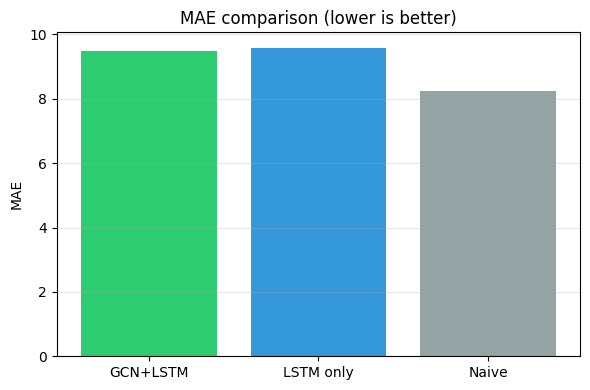

In [44]:
# Overall MAE comparison (all Q steps, test set)
if len(X_test) > 0 and "pred_test" in dir() and "pred_lstm" in dir():
    naive_pred = np.broadcast_to(X_test[:, -1:, :], (X_test.shape[0], Q, X_test.shape[2]))
    mae_gcn, mape_gcn, rmse_gcn = mae_mape_rmse(Y_test, pred_test)
    mae_lstm, mape_lstm, rmse_lstm = mae_mape_rmse(Y_test, pred_lstm)
    mae_naive, mape_naive, rmse_naive = mae_mape_rmse(Y_test, naive_pred)

    # Table
    import pandas as pd
    df_mae = pd.DataFrame({
        "Method": ["GCN+LSTM", "LSTM only", "Naive"],
        "MAE": [mae_gcn, mae_lstm, mae_naive],
        "MAPE (%)": [mape_gcn, mape_lstm, mape_naive],
        "RMSE": [rmse_gcn, rmse_lstm, rmse_naive],
    })
    print("MAE comparison (paper metrics, test set):")
    print(df_mae.to_string(index=False))

    # Bar chart: MAE only
    fig, ax = plt.subplots(figsize=(6, 4))
    x = np.arange(3)
    ax.bar(x, [mae_gcn, mae_lstm, mae_naive], color=["#2ecc71", "#3498db", "#95a5a6"])
    ax.set_xticks(x)
    ax.set_xticklabels(["GCN+LSTM", "LSTM only", "Naive"])
    ax.set_ylabel("MAE")
    ax.set_title("MAE comparison (lower is better)")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Run evaluation and baseline cells first.")

## MAE per prediction step (paper Fig 5)

Plot MAE at each future step (1, 2, …, Q) for GCN+LSTM vs LSTM-only to see if GCN helps more at longer horizons.

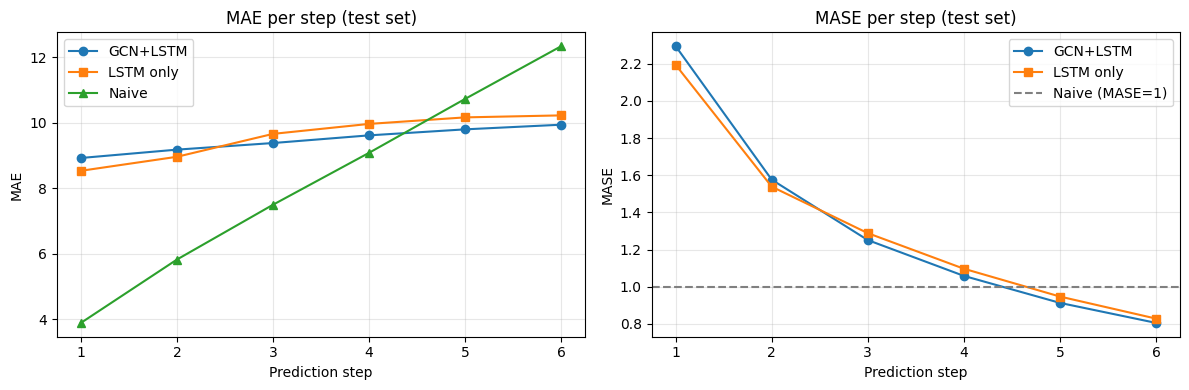

In [43]:
import matplotlib.pyplot as plt

if len(X_test) > 0 and "pred_test" in dir() and "pred_lstm" in dir():
    # Naive: last observed value (repeat for all Q steps)
    naive_pred = np.broadcast_to(X_test[:, -1:, :], (X_test.shape[0], Q, X_test.shape[2]))
    maes_gcn = [float(np.mean(np.abs(Y_test[:, s] - pred_test[:, s]))) for s in range(Q)]
    maes_lstm = [float(np.mean(np.abs(Y_test[:, s] - pred_lstm[:, s]))) for s in range(Q)]
    maes_naive = [float(np.mean(np.abs(Y_test[:, s] - naive_pred[:, s]))) for s in range(Q)]
    # MASE at step s = MAE(model) / MAE(naive) at that step
    mase_gcn = [maes_gcn[s] / (maes_naive[s] + 1e-12) for s in range(Q)]
    mase_lstm = [maes_lstm[s] / (maes_naive[s] + 1e-12) for s in range(Q)]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    steps = range(1, Q + 1)
    ax1.plot(steps, maes_gcn, "o-", label="GCN+LSTM")
    ax1.plot(steps, maes_lstm, "s-", label="LSTM only")
    ax1.plot(steps, maes_naive, "^-", label="Naive")
    ax1.set_xlabel("Prediction step")
    ax1.set_ylabel("MAE")
    ax1.set_title("MAE per step (test set)")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax2.plot(steps, mase_gcn, "o-", label="GCN+LSTM")
    ax2.plot(steps, mase_lstm, "s-", label="LSTM only")
    ax2.axhline(1.0, color="gray", linestyle="--", label="Naive (MASE=1)")
    ax2.set_xlabel("Prediction step")
    ax2.set_ylabel("MASE")
    ax2.set_title("MASE per step (test set)")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Run evaluation and baseline cells first.")